# 🏆 Notebook 4 — Model Comparison & Conclusions
**Dataset:** Stellar Classification (SDSS)

This notebook loads all saved predictions and produces a unified comparison:
1. Accuracy, Precision, Recall, F1 summary table
2. Per-class error rate bar chart
3. Training time comparison
4. Precision-Recall curves (per class, all models)
5. Final recommendations


## 0. Load All Predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from warnings import filterwarnings
filterwarnings('ignore')

# KNN & Decision Tree
with open('predictions/knn_dt.pkl', 'rb') as f:
    knn_dt = pickle.load(f)

# FNN
with open('predictions/fnn.pkl', 'rb') as f:
    fnn = pickle.load(f)

# Encoder
with open('data/encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

y_test      = knn_dt['y_test']
y_pred_knn  = knn_dt['y_pred_knn']
y_pred_dt   = knn_dt['y_pred_dt']
y_pred_fnn  = fnn['y_pred_fnn']
y_pred_proba_fnn = fnn['y_pred_proba']
knn_time    = knn_dt['knn_time']
dt_time     = knn_dt['dt_time']
fnn_time    = fnn['fnn_time']

# KNN & DT probabilities — reload models
with open('models/knn_best.pkl', 'rb') as f:
    clf_knn = pickle.load(f)
with open('models/dt_best.pkl', 'rb') as f:
    clf_dt = pickle.load(f)

with open('data/splits.pkl', 'rb') as f:
    X_train, X_test, _, _ = pickle.load(f)

class_names = encoder.classes_
print("All predictions loaded. Classes:", class_names)


All predictions loaded. Classes: ['GALAXY' 'QSO' 'STAR']


## 1. Summary Metrics Table

In [2]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

rows = [
    get_metrics(y_test, y_pred_knn, 'KNN'),
    get_metrics(y_test, y_pred_dt,  'Decision Tree'),
    get_metrics(y_test, y_pred_fnn, 'FNN'),
]

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())


               Accuracy  Precision  Recall  F1-Score
Model                                               
KNN              0.9366     0.9374  0.9366    0.9368
Decision Tree    0.9692     0.9694  0.9692    0.9691
FNN              0.9615     0.9622  0.9615    0.9614


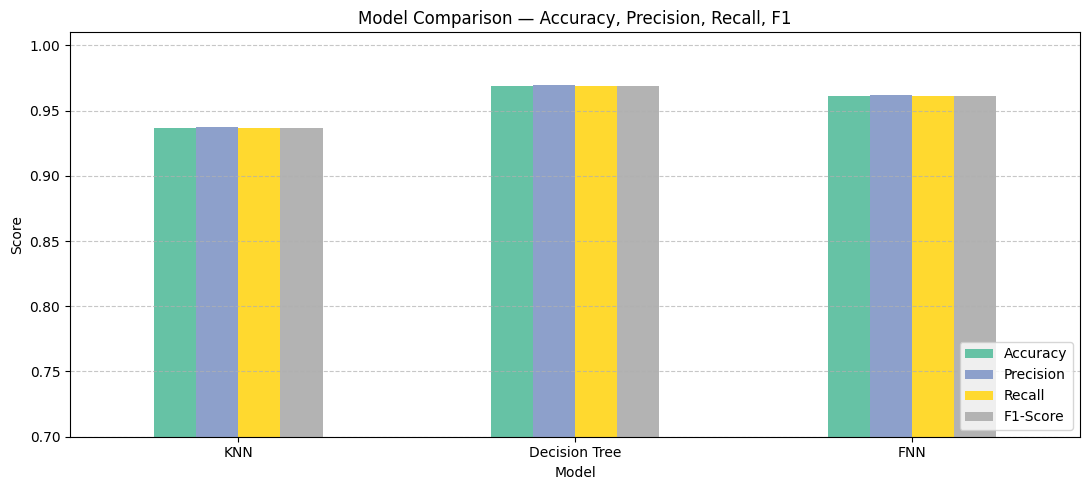

In [3]:
# Visual comparison bar chart
summary_df.plot(kind='bar', figsize=(11, 5), colormap='Set2')
plt.title('Model Comparison — Accuracy, Precision, Recall, F1')
plt.ylabel('Score')
plt.ylim(0.7, 1.01)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 2. Per-Class Error Rate (1 − Recall)

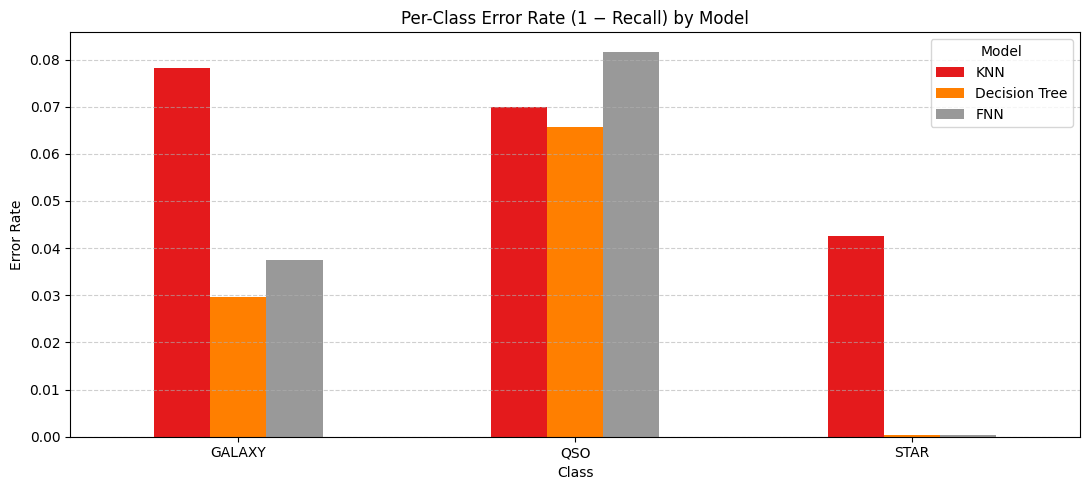

           KNN  Decision Tree     FNN
Classe                               
GALAXY  0.0782         0.0297  0.0375
QSO     0.0700         0.0657  0.0817
STAR    0.0426         0.0004  0.0004


In [4]:
def class_error_rates(y_true, y_pred, class_names, model_name):
    report = classification_report(y_true, y_pred,
                                   target_names=class_names, output_dict=True)
    return {cls: 1 - report[cls]['recall'] for cls in class_names}

error_knn = class_error_rates(y_test, y_pred_knn, class_names, 'KNN')
error_dt  = class_error_rates(y_test, y_pred_dt,  class_names, 'Decision Tree')
error_fnn = class_error_rates(y_test, y_pred_fnn, class_names, 'FNN')

error_df = pd.DataFrame({
    'Classe':        class_names,
    'KNN':           [error_knn[c] for c in class_names],
    'Decision Tree': [error_dt[c]  for c in class_names],
    'FNN':           [error_fnn[c] for c in class_names],
}).set_index('Classe')

error_df.plot(kind='bar', figsize=(11, 5), colormap='Set1')
plt.title("Per-Class Error Rate (1 − Recall) by Model")
plt.ylabel("Error Rate")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(error_df.round(4))


## 3. Training Time Comparison

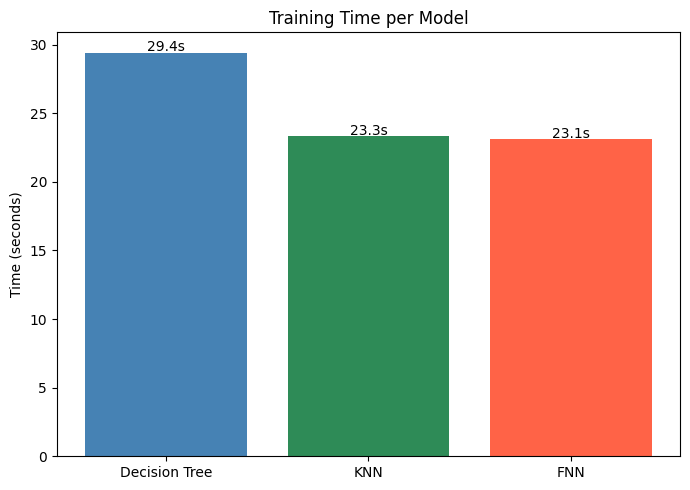

In [5]:
times = {
    'Decision Tree': dt_time,
    'KNN':           knn_time,
    'FNN':           fnn_time
}

plt.figure(figsize=(7, 5))
bars = plt.bar(times.keys(), times.values(), color=['steelblue', 'seagreen', 'tomato'])
plt.title("Training Time per Model")
plt.ylabel("Time (seconds)")
for bar, val in zip(bars, times.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{val:.1f}s', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Note:** KNN has no real "training" phase (lazy learner) — it just memorises
the data. Its reported time includes the full K-sweep loop.
Decision Tree trains quickly due to greedy splitting.
FNN requires the most compute but gains from gradient-based optimisation.


## 4. Precision-Recall Curves (Per Class, All Models)

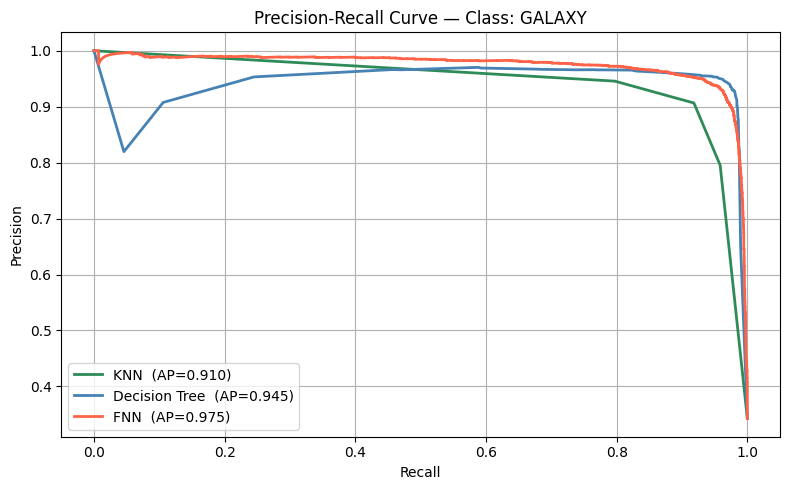

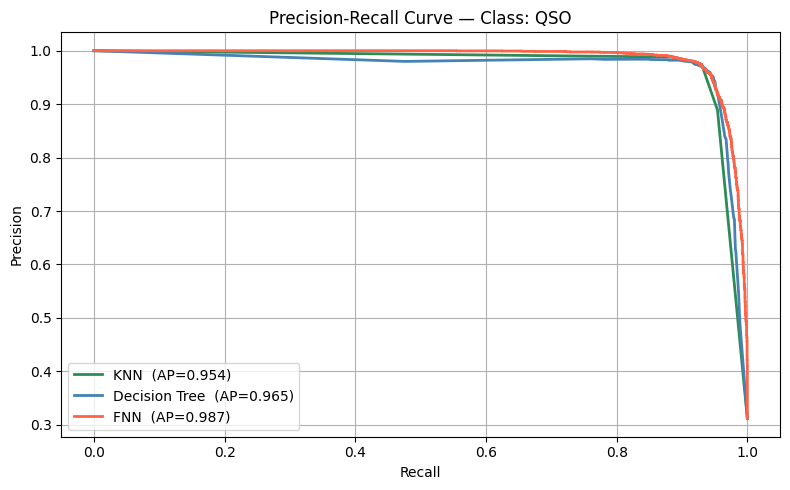

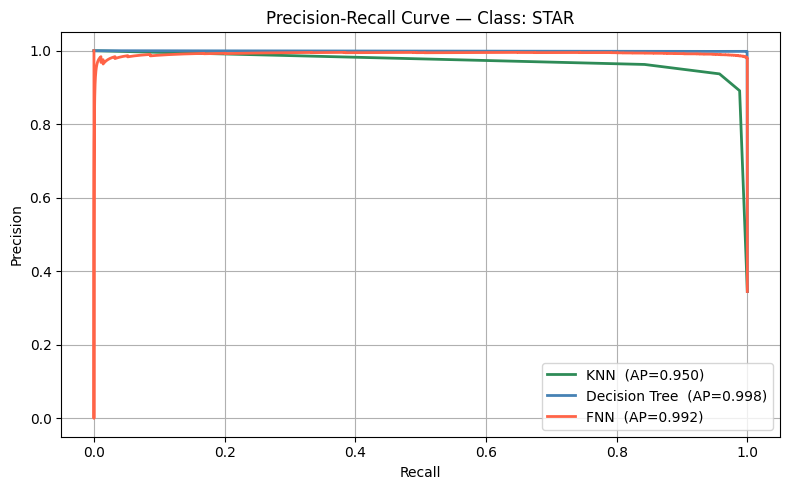

In [6]:
y_test_bin     = label_binarize(y_test, classes=[0, 1, 2])
y_proba_knn    = clf_knn.predict_proba(X_test)
y_proba_dt     = clf_dt.predict_proba(X_test)
y_proba_fnn    = y_pred_proba_fnn

model_probas = {
    'KNN':           y_proba_knn,
    'Decision Tree': y_proba_dt,
    'FNN':           y_proba_fnn
}
colors = {'KNN': 'seagreen', 'Decision Tree': 'steelblue', 'FNN': 'tomato'}

for i, cls in enumerate(class_names):
    plt.figure(figsize=(8, 5))
    for model_name, proba in model_probas.items():
        p, r, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        ap = average_precision_score(y_test_bin[:, i], proba[:, i])
        plt.plot(r, p, color=colors[model_name], lw=2,
                 label=f'{model_name}  (AP={ap:.3f})')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — Class: {cls}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 5. Final Conclusions

### Performance Summary

| Model | Strengths | Weaknesses |
|---|---|---|
| **KNN** | Simple, no training phase, good baseline | Slow at prediction, sensitive to irrelevant features |
| **Decision Tree** | Interpretable, fast, stable precision at high recall | Prone to overfitting; sensitive to small data changes |
| **FNN** | Learns complex non-linear patterns, well-regularised | Slower to train, more hyperparameters to tune |

### Recommended Model: **Decision Tree** or **FNN**
- Decision Tree is the best choice when **interpretability** matters
  (its if-then rules can be explained to domain experts in astronomy).
- FNN is preferred when **maximum accuracy** is the goal and compute is available.

### Key Predictors
Based on correlation analysis and Decision Tree splits, the most informative features are:
- Photometric bands: **u, g, r, i, z** (flux in different wavelength ranges)
- **redshift** — highly discriminative between QSO and other classes

### Suggested Improvements
1. **Random Forest / XGBoost** — ensemble methods that improve on single Decision Trees
2. **PCA or t-SNE** — dimensionality reduction for better feature separation visualisation
3. **SMOTE** instead of undersampling — generates synthetic minority samples, preserving more data
4. **F2-Score** as primary metric — if recall (completeness) is more important than precision
   (e.g. missing a QSO is worse than a false alarm)
